# 🛰️ DeepSpace — Satellite Image Super-Resolution Pipeline
### VS Code + Colab Extension Notebook

This notebook runs the full DeepSpace pipeline using the **VS Code Colab extension**  
(your local workspace is already open — no need to clone the repo).

1. **Setup** — install dependencies on the Colab runtime
2. **Mount Drive** — link your image data from Google Drive
3. **Train** — train the WaveletNCSNpp super-resolution model
4. **Fine-tune** *(optional)* — few-shot fine-tuning on a new region
5. **Inference** — reconstruct low-res satellite images to 256×256
6. **Evaluate** — compute PSNR / SSIM metrics
7. **Visualize** — display input / output image pairs
8. **Save** — persist checkpoints back to Drive

> ⚡ **Runtime tip:** Go to *Runtime → Change runtime type → T4 GPU* before running.
>
> 📂 **About the data:** The `*.png` images are in `.gitignore` and are not in the GitHub repo.  
> They need to be stored in Google Drive and mounted each session (see Step 2).

In [18]:
# ── Cell 1: Verify GPU ──────────────────────────────────────────────────────
import torch

if torch.cuda.is_available():
    print(f"✅ GPU: {torch.cuda.get_device_name(0)}")
    print(f"   VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
else:
    print("⚠️  No GPU detected. Go to Runtime → Change runtime type → T4 GPU.")

print(f"   PyTorch: {torch.__version__}")

✅ GPU: Tesla T4
   VRAM: 15.6 GB
   PyTorch: 2.10.0+cu128


## Step 1 — Install Dependencies on the Colab Runtime

Your code is already open via the VS Code Colab extension.  
This cell just installs the Python packages on the remote Colab runtime.

In [27]:
import os

REPO_URL     = "https://github.com/sophiasimons/DeepSpace.git"
REPO_DIR     = "/content/DeepSpace"
DECOMPRESS   = f"{REPO_DIR}/decompress"

if not os.path.exists(REPO_DIR):
    !git clone {REPO_URL} {REPO_DIR}
else:
    print("Repo already cloned — resetting to latest...")
    !git -C {REPO_DIR} fetch origin
    !git -C {REPO_DIR} reset --hard origin/main

%cd {DECOMPRESS}

print("Working directory:", os.getcwd())
assert os.path.exists("train_srwddgan.py"), "train_srwddgan.py not found — check working directory"
print("✅ Workspace ready.")


Repo already cloned — resetting to latest...
remote: Enumerating objects: 9, done.
remote: Counting objects: 100% (9/9), done.
remote: Compressing objects: 100% (1/1), done.
remote: Total 5 (delta 4), reused 5 (delta 4), pack-reused 0 (from 0)
Unpacking objects: 100% (5/5), 507 bytes | 507.00 KiB/s, done.
From https://github.com/sophiasimons/DeepSpace
   a4b7ae8..b5b84af  main       -> origin/main
HEAD is now at b5b84af fix: base dataset_len on min of hr/sr/lr path lengths to prevent IndexError
/content/DeepSpace/decompress
Working directory: /content/DeepSpace/decompress
✅ Workspace ready.


In [21]:
# Install PyTorch (CUDA 12.1) and project dependencies
!pip install -q torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu121

!pip install -q \
    pytorch_wavelets==1.3.0 \
    einops \
    lmdb \
    Pillow \
    scikit-image \
    lpips \
    imagehash \
    ninja

print("✅ Dependencies installed.")

✅ Dependencies installed.


In [22]:
import os, torch

# T4 = compute 7.5 | A100 = 8.0 | V100 = 7.0
# Setting this ensures the JIT-compiled CUDA kernels target the right GPU arch.
os.environ["TORCH_CUDA_ARCH_LIST"] = "7.5"   # T4
# os.environ["TORCH_CUDA_ARCH_LIST"] = "8.0" # uncomment for A100

if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

    # Force recompile of the upfirdn2d and fused_bias_act kernels now,
    # before training starts, so any compile error is visible immediately.
    import sys
    sys.path.insert(0, os.path.join(os.getcwd(), "score_sde", "op"))
    try:
        from score_sde.op import upfirdn2d as _ufd
        from score_sde.op import fused_act as _fa
        print("✅ CUDA extensions compiled successfully.")
    except Exception as e:
        print(f"⚠️  CUDA extension compile failed: {e}")
        print("   Training will use slower CPU fallbacks — this is OK but will be slow.")
else:
    print("No CUDA available — CUDA extensions skipped.")

GPU: Tesla T4
✅ CUDA extensions compiled successfully.


## Step 2 — Mount Google Drive & Link Data

The image data (`*.png`) is excluded from the GitHub repo via `.gitignore`, so it needs to live in Google Drive.

**One-time setup:** upload your data to Drive at:
```
MyDrive/DeepSpace/data/
  deepgreen_16_256/
    hr_256/        ← 256×256 high-res images   (25,415 images)
    lr_16/         ← 16×16 low-res inputs
    sr_16_256/     ← bicubic upsampled (model input)
```
To zip and upload from your Mac:
```bash
cd /Users/sophiasimons/DeepSpace-1/decompress/data
zip -r ~/Desktop/deepgreen_16_256.zip deepgreen_16_256/
```
Then upload `deepgreen_16_256.zip` to `MyDrive/DeepSpace/data/` in Google Drive and unzip it there.

In [23]:
from google.colab import drive

drive.mount("/content/drive")

# ── Configure this path ────────────────────────────────────────────────────
DRIVE_DATA_DIR = "/content/drive/MyDrive/DeepSpace/data"   # ← edit if needed
# ──────────────────────────────────────────────────────────────────────────

# Symlink Drive data into the workspace's data/ folder so training scripts
# find it at the expected relative path (./data/deepgreen_16_256)
local_data_dir = os.path.join(os.getcwd(), "data")
os.makedirs(local_data_dir, exist_ok=True)

symlink_target = os.path.join(local_data_dir, "deepgreen_16_256")
drive_source   = os.path.join(DRIVE_DATA_DIR, "deepgreen_16_256")

if not os.path.exists(symlink_target):
    os.symlink(drive_source, symlink_target)
    print(f"✅ Symlink created: data/deepgreen_16_256 → Drive")
else:
    print("Symlink already exists.")

DATADIR = "./data/deepgreen_16_256"

# Sanity check
hr_dir = os.path.join(symlink_target, "hr_256")
hr_count = len(os.listdir(hr_dir)) if os.path.exists(hr_dir) else 0
print(f"   hr_256 images found: {hr_count}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Symlink created: data/deepgreen_16_256 → Drive
   hr_256 images found: 25476


## Step 3 — Train the Model

Trains the WaveletNCSNpp GAN from scratch on your dataset.  
Checkpoints are saved every epoch to `content/saved_info/`.

In [25]:
# ── Training configuration ────────────────────────────────────────────────
DATASET    = "deepgreen_16_256"
# DATADIR is set in Step 2 — do not override here
EXP        = "deepspace_colab"

# ── Time estimates on T4 (~1–2 sec/step) ─────────────────────────────────
# DATA_LEN controls how many images are used per epoch.
# Full dataset = 12,700 train images → ~3,175 steps/epoch → ~9–18 hrs for 10 epochs
# Set DATA_LEN to limit images and stay within Colab's ~12 hr session:
#
#   DATA_LEN=200,  NUM_EPOCH=10  → ~50 steps/epoch  →  ~10–20 min  (smoke test)
#   DATA_LEN=2000, NUM_EPOCH=10  → ~500 steps/epoch →  ~1.5–3 hrs  (sanity check)
#   DATA_LEN=0,    NUM_EPOCH=3   → full dataset, 3 epochs → ~3–6 hrs (real training)
#
# For a first Colab run, start with DATA_LEN=2000 to confirm everything works,
# then set DATA_LEN=0 (no limit) for a proper training run on a Pro runtime.
DATA_LEN   = 200   # 0 = use full dataset
NUM_EPOCH  = 1
# ⚠️  BATCH_SIZE must be divisible by 4 (discriminator stddev_group=4 constraint)
# T4 (16 GB): 4 or 8.  A100 (40 GB): 8 or 16.
BATCH_SIZE = 4
# ──────────────────────────────────────────────────────────────────────────

# Kill any stale torch.distributed processes still holding ports
import subprocess, socket

def find_free_port(start=6010, end=6099):
    for port in range(start, end):
        with socket.socket(socket.AF_INET, socket.SOCK_STREAM) as s:
            if s.connect_ex(('localhost', port)) != 0:
                return port
    raise RuntimeError("No free port found in range")

# Kill leftover python training processes (safe — only kills previous !python calls)
subprocess.run("pkill -f train_srwddgan.py", shell=True)

MASTER_PORT = find_free_port()
print(f"Using master port: {MASTER_PORT}")

data_len_flag = f"--data_len {DATA_LEN}" if DATA_LEN > 0 else ""

!python train_srwddgan.py \
    --dataset {DATASET} \
    --datadir {DATADIR} \
    --exp {EXP} \
    --num_epoch {NUM_EPOCH} \
    --batch_size {BATCH_SIZE} \
    {data_len_flag} \
    --image_size 256 \
    --current_resolution 128 \
    --l_resolution 16 \
    --h_resolution 256 \
    --num_channels 24 \
    --num_channels_dae 64 \
    --ch_mult 1 2 2 2 4 \
    --num_timesteps 2 \
    --num_res_blocks 2 \
    --ngf 64 \
    --embedding_type positional \
    --use_ema \
    --r1_gamma 2. \
    --cond_emb_dim 256 \
    --lr_d 1e-4 \
    --lr_g 2e-4 \
    --lazy_reg 10 \
    --num_disc_layers 6 \
    --attn_resolutions 16 \
    --rec_loss \
    --use_pytorch_wavelet \
    --net_type wavelet \
    --num_process_per_node 1 \
    --master_port {MASTER_PORT} \
    --save_content \
    --save_content_every 1 \
    --save_ckpt_every 5


Using master port: 6010
starting in debug mode
Rank 0 initialized
Using device: cuda
GEN: <class 'score_sde.models.ncsnpp_generator_adagn.WaveletNCSNpp'>, DISC: large images disc

Using pytorch_wavelets
Starting training loop. 

[rank0]:[W419 22:47:23.055072152 reducer.cpp:1500] Warning: find_unused_parameters=True was specified in DDP constructor, but did not find any unused parameters in the forward pass. This flag results in an extra traversal of the autograd graph every iteration,  which can adversely affect performance. If your model indeed never has any unused parameters in the forward pass, consider turning this flag off. Note that this warning may be a false positive if your model has flow control causing later iterations to have unused parameters. (function operator())
Content saving disabled.
Content saving disabled.
Content saving disabled.
Content saving disabled.
Content saving disabled.
checkpoint saved.
Content saving disabled.
Content saving disabled.
Content saving dis

## Step 4 — (Optional) Few-Shot Fine-Tune on a New Region

Skip this step if you only need the base model.  
Fine-tuning adapts the model to a new geographic region using just 50–100 images.

In [ ]:
# ── Fine-tune configuration ───────────────────────────────────────────────
FOUNDATION_CKPT   = f"./content/saved_info/wddgan/{EXP}/{EXP}/netG_final.pth"
NEW_REGION_DIR    = "/content/drive/MyDrive/DeepSpace/data/new_region"  # ← edit
FINETUNE_EXP      = "deepspace_finetuned"
FINETUNE_EPOCHS   = 30
FINETUNE_DATA_LEN = 100
# ──────────────────────────────────────────────────────────────────────────

!python finetune_srwddgan.py \
    --foundation_ckpt {FOUNDATION_CKPT} \
    --dataset deepgreen_16_256 \
    --datadir {NEW_REGION_DIR} \
    --exp {FINETUNE_EXP} \
    --data_len {FINETUNE_DATA_LEN} \
    --num_epoch {FINETUNE_EPOCHS} \
    --batch_size 4 \
    --image_size 256 \
    --current_resolution 128 \
    --l_resolution 16 \
    --h_resolution 256 \
    --num_channels 24 \
    --num_channels_dae 64 \
    --ch_mult 1 2 2 2 4 \
    --num_timesteps 2 \
    --num_res_blocks 2 \
    --ngf 64 \
    --embedding_type positional \
    --use_ema \
    --r1_gamma 2. \
    --cond_emb_dim 256 \
    --lazy_reg 10 \
    --num_disc_layers 6 \
    --attn_resolutions 16 \
    --rec_loss \
    --use_pytorch_wavelet \
    --net_type wavelet \
    --num_process_per_node 1 \
    --master_port 6002 \
    --lr_g 5e-5 \
    --lr_d 2e-5

usage: DeepSpace foundation model fine-tuning [-h] [--seed SEED]
                                              --foundation_ckpt
                                              FOUNDATION_CKPT
                                              [--dataset DATASET]
                                              [--datadir DATADIR]
                                              [--data_len DATA_LEN]
                                              [--l_resolution L_RESOLUTION]
                                              [--h_resolution H_RESOLUTION]
                                              [--exp EXP]
                                              [--num_epoch NUM_EPOCH]
                                              [--batch_size BATCH_SIZE]
                                              [--lr_g LR_G] [--lr_d LR_D]
                                              [--beta1 BETA1] [--beta2 BETA2]
                                              [--r1_gamma R1_GAMMA]
                                     

## Step 5 — Run Inference (Reconstruct Images)

In [29]:
# ── Inference configuration ───────────────────────────────────────────────
INFER_EXP   = EXP        # or FINETUNE_EXP for the fine-tuned model
EPOCH_ID    = NUM_EPOCH  # which checkpoint epoch to load
NUM_ITERS   = 50         # number of batches to run (total images = NUM_ITERS × batch_size)
# ──────────────────────────────────────────────────────────────────────────

RESULTS_DIR = f"./content/results/{INFER_EXP}"

!python test_srwddgan.py \
    --dataset {DATASET} \
    --datadir {DATADIR} \
    --exp {INFER_EXP} \
    --epoch_id {EPOCH_ID} \
    --image_size 256 \
    --current_resolution 128 \
    --l_resolution 16 \
    --h_resolution 256 \
    --num_channels 24 \
    --num_channels_dae 64 \
    --ch_mult 1 2 2 2 4 \
    --num_timesteps 2 \
    --num_res_blocks 2 \
    --embedding_type positional \
    --cond_emb_dim 256 \
    --attn_resolutions 16 \
    --use_pytorch_wavelet \
    --net_type wavelet \
    --batch_size 4 \
    --num_iters {NUM_ITERS}

print(f"✅ Results saved to {RESULTS_DIR}")


Using device: cuda:0
128 [1, 2, 2, 2, 4] [16]
GEN: <class 'score_sde.models.ncsnpp_generator_adagn.WaveletNCSNpp'>
iteration:  0
Results are saved at tot_sr_id0.jpg
iteration:  1
Results are saved at tot_sr_id1.jpg
iteration:  2
Results are saved at tot_sr_id2.jpg
iteration:  3
Results are saved at tot_sr_id3.jpg
iteration:  4
Results are saved at tot_sr_id4.jpg
iteration:  5
Results are saved at tot_sr_id5.jpg
iteration:  6
Results are saved at tot_sr_id6.jpg
iteration:  7
Results are saved at tot_sr_id7.jpg
iteration:  8
Results are saved at tot_sr_id8.jpg
iteration:  9
Results are saved at tot_sr_id9.jpg
iteration:  10
Results are saved at tot_sr_id10.jpg
iteration:  11
Results are saved at tot_sr_id11.jpg
iteration:  12
Results are saved at tot_sr_id12.jpg
iteration:  13
Results are saved at tot_sr_id13.jpg
iteration:  14
Results are saved at tot_sr_id14.jpg
iteration:  15
Results are saved at tot_sr_id15.jpg
iteration:  16
Results are saved at tot_sr_id16.jpg
iteration:  17
Result

## Step 6 — Evaluate (PSNR / SSIM)

## Step 6b — Baseline Comparison: Real-ESRGAN vs DeepSpace

This section runs **Real-ESRGAN** (a state-of-the-art general-purpose SR model pre-trained on natural images) on the same low-res satellite inputs, then displays a 4-way comparison:

| LR input (16×16) | Bicubic (256×256) | Real-ESRGAN (×4 → 64×64) | **DeepSpace** (256×256) | HR ground truth |
|---|---|---|---|---|

> Real-ESRGAN is not trained on satellite imagery — that's the point.  
> The gap between Real-ESRGAN and DeepSpace demonstrates the value of a domain-specific foundational model.


In [30]:
# ── Aggressive disk cleanup ───────────────────────────────────────────────
import shutil, subprocess

def show_disk():
    total, used, free = shutil.disk_usage("/")
    print(f"  Used: {used/1e9:.1f} GB   Free: {free/1e9:.1f} GB   Total: {total/1e9:.1f} GB")

print("Before:"); show_disk()
print()

# 1. pip / build caches
subprocess.run("pip cache purge -q 2>/dev/null || true", shell=True)
subprocess.run("rm -rf /root/.cache/pip /tmp/pip-* /tmp/*.whl /tmp/*.egg-info", shell=True)

# 2. basicsr / BasicSR git build remnants (the main culprit — can be 3–5 GB)
subprocess.run("rm -rf /tmp/pip-build-* /tmp/BasicSR* /tmp/basicsr*", shell=True)
subprocess.run("find /tmp -maxdepth 2 -name '*.so' -delete 2>/dev/null || true", shell=True)
subprocess.run("find /tmp -maxdepth 3 -name 'build' -type d -exec rm -rf {} + 2>/dev/null || true", shell=True)

# 3. torch JIT / triton compile cache
subprocess.run("rm -rf /root/.cache/torch /root/.cache/triton", shell=True)

# 4. apt cache
subprocess.run("apt-get clean -q 2>/dev/null || true", shell=True)

# 5. Show what's left in /tmp and /root/.cache so you can see what took space
print("\nRemaining in /tmp (> 10 MB):")
subprocess.run("find /tmp -maxdepth 2 -size +10M 2>/dev/null | xargs du -sh 2>/dev/null | sort -rh | head -20", shell=True)

print("\nRemaining in /root/.cache:")
subprocess.run("du -sh /root/.cache/* 2>/dev/null | sort -rh | head -10", shell=True)

print("\nAfter:"); show_disk()
print("✅ Done.")


Before:
  Used: 49.9 GB   Free: 71.0 GB   Total: 120.9 GB


Remaining in /tmp (> 10 MB):

Remaining in /root/.cache:

After:
  Used: 49.9 GB   Free: 71.0 GB   Total: 120.9 GB
✅ Done.


In [31]:
# ── Install basicsr (PyPI wheel — ~50 MB, no C++ build) ──────────────────
# basicsr 1.4.2 imports torchvision.transforms.functional_tensor which was
# removed in torchvision 0.17+.  We install the small PyPI wheel and shim
# the missing module with a one-liner before any basicsr import.
import sys, types, torchvision.transforms.functional as _F

# Create a fake functional_tensor module that re-exports everything from
# torchvision.transforms.functional (the functions basicsr actually uses
# — rgb_to_grayscale, normalize, etc. — all still exist there).
_shim = types.ModuleType("torchvision.transforms.functional_tensor")
_shim.__dict__.update({k: v for k, v in _F.__dict__.items() if not k.startswith("__")})
sys.modules["torchvision.transforms.functional_tensor"] = _shim
print("✅ torchvision shim applied.")

!pip install -q --no-cache-dir basicsr
!pip cache purge -q 2>/dev/null || true

import shutil
total, used, free = shutil.disk_usage("/")
print(f"✅ basicsr installed.  Disk free: {free/1e9:.1f} GB / {total/1e9:.1f} GB")


✅ torchvision shim applied.
✅ basicsr installed.  Disk free: 71.0 GB / 120.9 GB


✅ Real-ESRGAN model loaded (RealESRGAN_x4plus, 4× upscale).
✅ Processed 4 images.


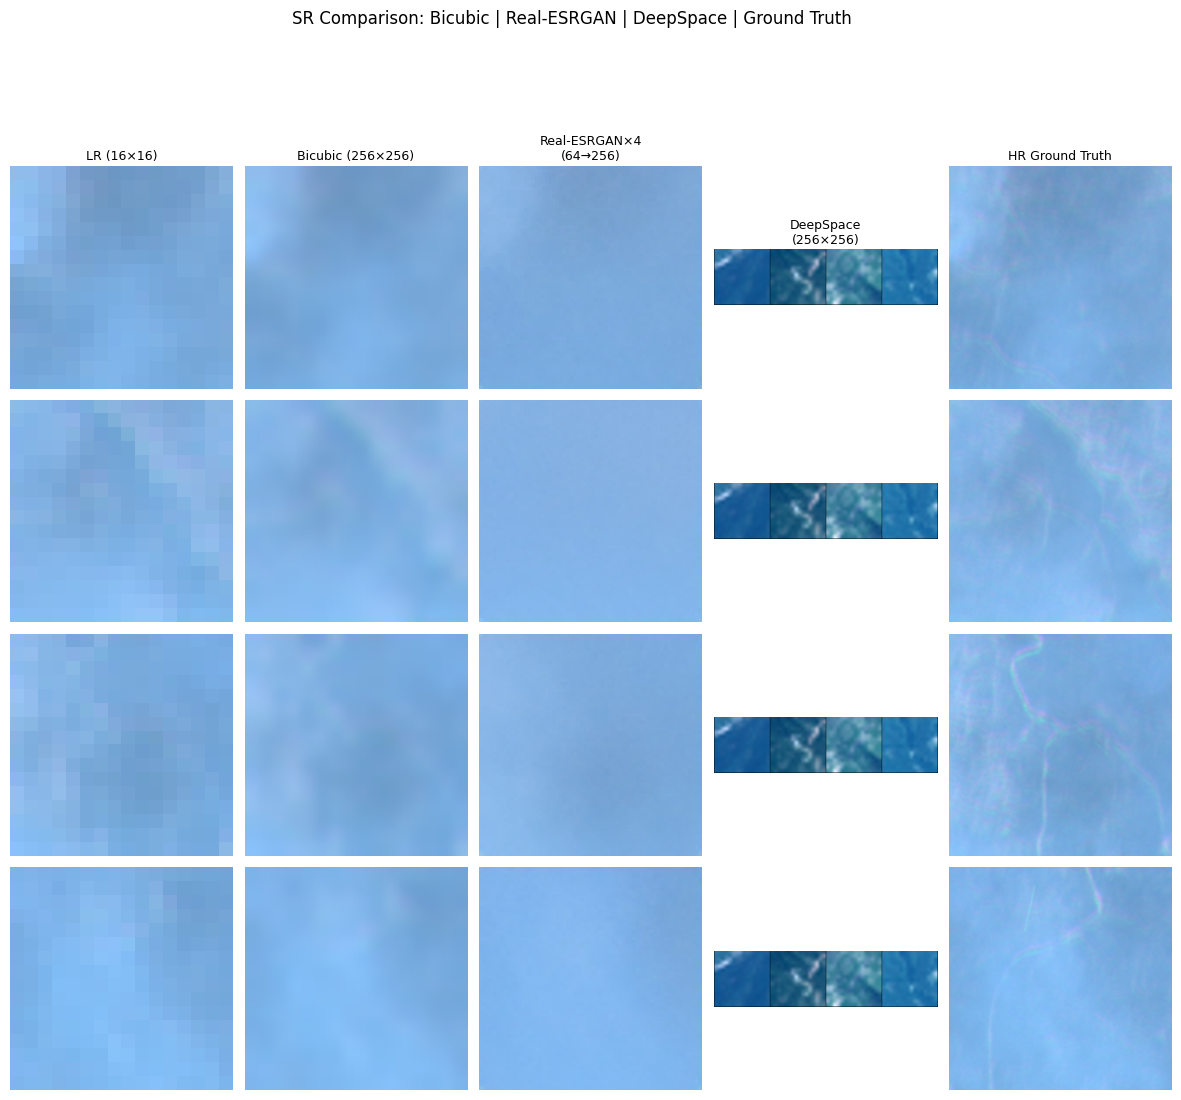

✅ Comparison saved to sr_comparison.png


In [32]:
import os, glob, torch, urllib.request
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from PIL import Image

# ── Configuration ─────────────────────────────────────────────────────────
DATASET      = "deepgreen_16_256"
EXP          = "deepspace_colab"
NUM_EPOCH    = 1           # epoch checkpoint to load for DeepSpace results
NUM_COMPARE  = 4           # number of image examples to show
DATADIR      = "./data/deepgreen_16_256"
# ──────────────────────────────────────────────────────────────────────────

# ── Load Real-ESRGAN weights via basicsr (no realesrgan package needed) ───
from basicsr.archs.rrdbnet_arch import RRDBNet

WEIGHTS_URL  = "https://github.com/xinntao/Real-ESRGAN/releases/download/v0.1.0/RealESRGAN_x4plus.pth"
WEIGHTS_PATH = "/tmp/RealESRGAN_x4plus.pth"

if not os.path.exists(WEIGHTS_PATH):
    print("Downloading Real-ESRGAN weights (~67 MB)...")
    urllib.request.urlretrieve(WEIGHTS_URL, WEIGHTS_PATH)
    print("  Done.")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

esrgan_model = RRDBNet(num_in_ch=3, num_out_ch=3, num_feat=64,
                        num_block=23, num_grow_ch=32, scale=4)
# The checkpoint is wrapped under the key 'params_ema' or 'params'
ckpt = torch.load(WEIGHTS_PATH, map_location=device)
state_dict = ckpt.get("params_ema", ckpt.get("params", ckpt))
esrgan_model.load_state_dict(state_dict, strict=True)
esrgan_model.eval().to(device)
print("✅ Real-ESRGAN model loaded (RealESRGAN_x4plus, 4× upscale).")

def esrgan_upscale(lr_np: np.ndarray) -> np.ndarray:
    """Upscale a uint8 HxWx3 numpy array 4× using Real-ESRGAN."""
    img = torch.from_numpy(lr_np).permute(2, 0, 1).float().div(255.0).unsqueeze(0).to(device)
    with torch.no_grad():
        out = esrgan_model(img).squeeze(0).clamp(0, 1)
    return (out.permute(1, 2, 0).cpu().numpy() * 255).astype(np.uint8)

# ── Gather images ─────────────────────────────────────────────────────────
lr_dir  = os.path.join(DATADIR, "lr_16")
sr_dir  = os.path.join(DATADIR, "sr_16_256")   # bicubic baseline
hr_dir  = os.path.join(DATADIR, "hr_256")

all_names    = sorted(os.listdir(hr_dir))
test_names   = all_names[len(all_names) // 2:]
sample_names = test_names[:NUM_COMPARE]

ds_results_dir = f"content/{DATASET}/{EXP}"

realesrgan_outs, bicubic_outs, deepspace_outs, hr_outs, lr_outs = [], [], [], [], []

for name in sample_names:
    stem = os.path.splitext(name)[0]

    lr_img = np.array(Image.open(os.path.join(lr_dir, name)).convert("RGB"))
    lr_outs.append(lr_img)

    bicubic_outs.append(np.array(Image.open(os.path.join(sr_dir, name)).convert("RGB")))
    hr_outs.append(np.array(Image.open(os.path.join(hr_dir, name)).convert("RGB")))

    # Real-ESRGAN: 16×16 → 64×64, then nearest-neighbour resize to 256 for display
    resr_64  = esrgan_upscale(lr_img)
    resr_256 = np.array(Image.fromarray(resr_64).resize((256, 256), Image.NEAREST))
    realesrgan_outs.append(resr_256)

    # DeepSpace output (from Step 5 inference)
    ds_candidates = glob.glob(f"{ds_results_dir}/sr_epoch_{NUM_EPOCH}_*.png")
    if ds_candidates:
        deepspace_outs.append(np.array(Image.open(sorted(ds_candidates)[0]).convert("RGB")))
    else:
        deepspace_outs.append(None)

print(f"✅ Processed {len(sample_names)} images.")

# ── Plot comparison ───────────────────────────────────────────────────────
cols   = ["LR (16×16)", "Bicubic (256×256)", "Real-ESRGAN×4\n(64→256)", "DeepSpace\n(256×256)", "HR Ground Truth"]
n_cols = len(cols)
fig    = plt.figure(figsize=(n_cols * 3, NUM_COMPARE * 3))
gs     = gridspec.GridSpec(NUM_COMPARE, n_cols, figure=fig, hspace=0.05, wspace=0.05)

for row in range(NUM_COMPARE):
    images = [lr_outs[row], bicubic_outs[row], realesrgan_outs[row], deepspace_outs[row], hr_outs[row]]
    for col, (img, title) in enumerate(zip(images, cols)):
        ax = fig.add_subplot(gs[row, col])
        if img is not None:
            ax.imshow(img)
        else:
            ax.text(0.5, 0.5, "Run inference\n(Step 5) first",
                    ha="center", va="center", transform=ax.transAxes, fontsize=8, color="gray")
            ax.set_facecolor("#f0f0f0")
        ax.axis("off")
        if row == 0:
            ax.set_title(title, fontsize=9, pad=4)

plt.suptitle("SR Comparison: Bicubic | Real-ESRGAN | DeepSpace | Ground Truth",
             fontsize=12, y=1.01)
plt.savefig("sr_comparison.png", bbox_inches="tight", dpi=150)
plt.show()
print("✅ Comparison saved to sr_comparison.png")


In [33]:
!python benchmark/eval.py -p {RESULTS_DIR}

Setting up [LPIPS] perceptual loss: trunk [alex], v[0.1], spatial [off]
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=AlexNet_Weights.IMAGENET1K_V1`. You can also use `weights=AlexNet_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Downloading: "https://download.pytorch.org/models/alexnet-owt-7be5be79.pth" to /root/.cache/torch/hub/checkpoints/alexnet-owt-7be5be79.pth
100% 233M/233M [00:01<00:00, 185MB/s]
Loading model from: /usr/local/lib/python3.12/dist-packages/lpips/weights/v0.1/alex.pth
Setting up [LPIPS] perceptual loss: trunk 

## Step 6b — Real-ESRGAN Benchmark vs. Planet-CAL Paper

Run **Real-ESRGAN** (×16: 16×16 → 256×256) on 10 satellite images from our dataset,
compute PSNR / SSIM / CR, and compare against the results reported in the DeepSpace paper
(Table 3, Planet-CAL dataset, CR=16 column).

No DeepSpace model training required — this cell runs standalone after Step 2 (Drive mount).


In [34]:
# ── Install deps (tiny PyPI wheel, no C++ build) ──────────────────────────
import sys, types, torchvision.transforms.functional as _F

# Shim the removed functional_tensor module so basicsr 1.4.x loads on Python 3.12
_shim = types.ModuleType("torchvision.transforms.functional_tensor")
_shim.__dict__.update({k: v for k, v in _F.__dict__.items() if not k.startswith("__")})
sys.modules["torchvision.transforms.functional_tensor"] = _shim

!pip install -q --no-cache-dir basicsr scikit-image pandas
!pip cache purge -q 2>/dev/null || true
print("✅ deps ready.")


✅ deps ready.


✅ Real-ESRGAN loaded on cuda.
Evaluating 10 images…
                   name  SR_SSIM   SR_PSNR  Interp_SSIM  Interp_PSNR         CR
2021-07-29_2307_101.png 0.938355 32.639034     0.948479    40.084772 133.437500
2021-07-29_2307_102.png 0.920267 30.968989     0.934132    38.717873 131.989474
2021-07-29_2307_103.png 0.898482 33.027470     0.910313    36.646986 136.421053
2021-07-29_2307_104.png 0.932505 34.121042     0.941535    39.142906 144.076389
2021-07-29_2307_105.png 0.921572 32.460167     0.931840    38.828384 139.800443
2021-07-29_2307_106.png 0.913913 33.280866     0.923689    37.701558 143.562077
2021-07-29_2307_107.png 0.903912 33.189697     0.913282    37.500554 147.481900
2021-07-29_2307_108.png 0.933832 34.920061     0.943387    39.941781 140.153670
2021-07-29_2307_109.png 0.957474 35.323605     0.965530    42.122359 136.535885
 2021-07-29_2307_11.png 0.896153 32.133912     0.907850    36.755677 141.181237


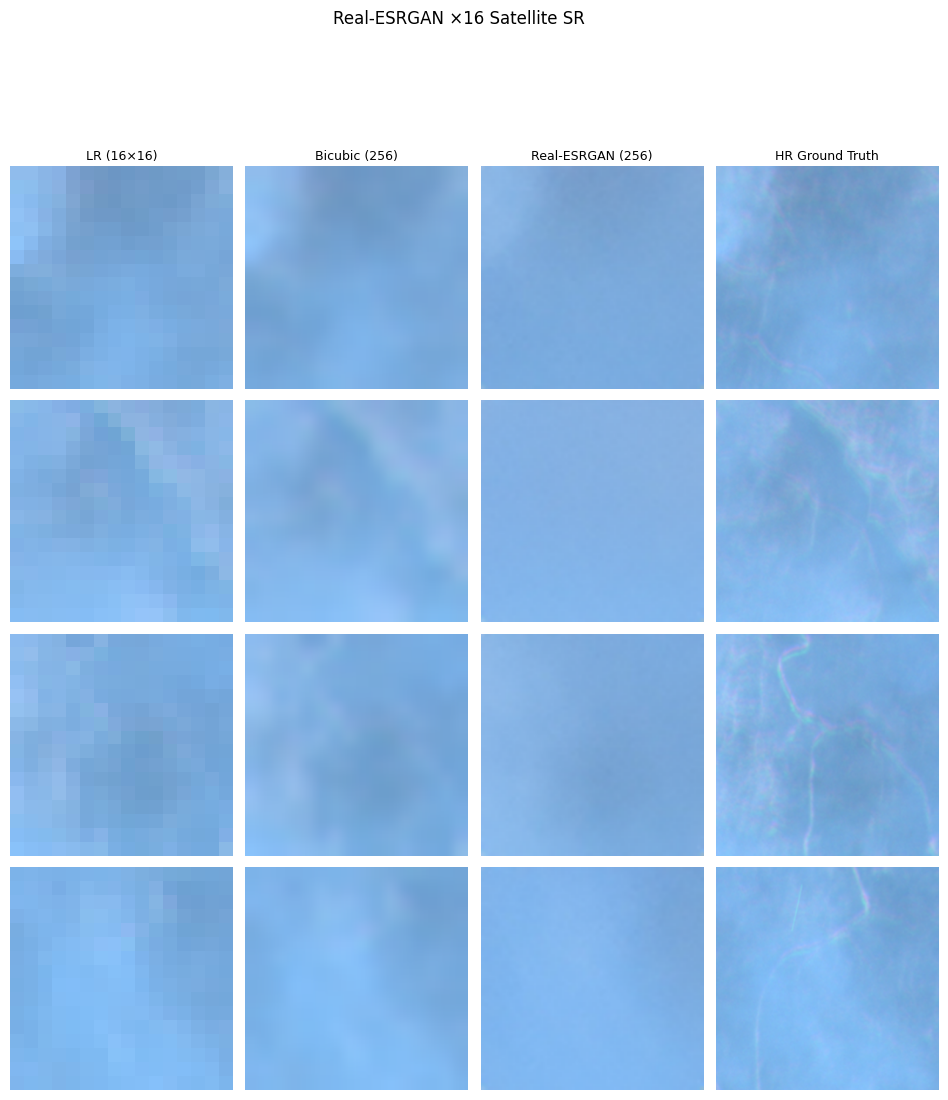

✅ Grid saved to realesrgan_comparison.png

====== Real-ESRGAN vs. Planet-CAL Paper ======
Metric                 Paper    Real-ESRGAN        Gap
------------------------------------------------------
Avg SSIM               0.950          0.922     -0.028
Min SSIM               0.900          0.896     -0.004
Avg PSNR              39.000         33.206     -5.794
Avg CR               146.400        139.464     -6.936

Bicubic interpolation baseline (paper: SSIM=0.89, PSNR=35.2 at CR=16):
  Avg SSIM : 0.932
  Avg PSNR : 38.7 dB


In [35]:
import os, urllib.request
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import torch
from PIL import Image
from skimage.metrics import structural_similarity as ssim_fn
from skimage.metrics import peak_signal_noise_ratio as psnr_fn

# ── Config ────────────────────────────────────────────────────────────────
DATADIR    = "./data/deepgreen_16_256"
NUM_IMAGES = 10
# ──────────────────────────────────────────────────────────────────────────

from basicsr.archs.rrdbnet_arch import RRDBNet

WEIGHTS_URL  = "https://github.com/xinntao/Real-ESRGAN/releases/download/v0.1.0/RealESRGAN_x4plus.pth"
WEIGHTS_PATH = "/tmp/RealESRGAN_x4plus.pth"
if not os.path.exists(WEIGHTS_PATH):
    print("Downloading Real-ESRGAN weights (~67 MB)…")
    urllib.request.urlretrieve(WEIGHTS_URL, WEIGHTS_PATH)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
esrgan = RRDBNet(num_in_ch=3, num_out_ch=3, num_feat=64,
                  num_block=23, num_grow_ch=32, scale=4)
ckpt = torch.load(WEIGHTS_PATH, map_location=device)
esrgan.load_state_dict(ckpt.get("params_ema", ckpt.get("params", ckpt)), strict=True)
esrgan.eval().to(device)
print(f"✅ Real-ESRGAN loaded on {device}.")

def esrgan_sr(lr_np):
    t = torch.from_numpy(lr_np).permute(2,0,1).float().div(255).unsqueeze(0).to(device)
    with torch.no_grad():
        out = esrgan(t).squeeze(0).clamp(0,1)
    return (out.permute(1,2,0).cpu().numpy() * 255).astype(np.uint8)

hr_dir = os.path.join(DATADIR, "hr_256")
lr_dir = os.path.join(DATADIR, "lr_16")
sr_dir = os.path.join(DATADIR, "sr_16_256")

all_names  = sorted(os.listdir(hr_dir))
test_names = all_names[len(all_names) // 2:][:NUM_IMAGES]
print(f"Evaluating {len(test_names)} images…")

records, vis_rows = [], []

for name in test_names:
    hr  = np.array(Image.open(os.path.join(hr_dir, name)).convert("RGB"))
    lr  = np.array(Image.open(os.path.join(lr_dir, name)).convert("RGB"))
    itp = np.array(Image.open(os.path.join(sr_dir, name)).convert("RGB"))

    sr_64  = esrgan_sr(lr)
    sr_256 = np.array(Image.fromarray(sr_64).resize((256, 256), Image.BICUBIC))

    sr_ssim  = ssim_fn(hr, sr_256, channel_axis=2, data_range=255)
    sr_psnr  = psnr_fn(hr, sr_256, data_range=255)
    itp_ssim = ssim_fn(hr, itp,    channel_axis=2, data_range=255)
    itp_psnr = psnr_fn(hr, itp,    data_range=255)

    hr_bytes = os.path.getsize(os.path.join(hr_dir, name))
    lr_bytes = os.path.getsize(os.path.join(lr_dir, name))
    cr = hr_bytes / lr_bytes

    records.append(dict(name=name, SR_SSIM=sr_ssim, SR_PSNR=sr_psnr,
                        Interp_SSIM=itp_ssim, Interp_PSNR=itp_psnr, CR=cr))
    if len(vis_rows) < 4:
        vis_rows.append((lr, itp, sr_256, hr))

df = pd.DataFrame(records)
print(df[["name","SR_SSIM","SR_PSNR","Interp_SSIM","Interp_PSNR","CR"]].to_string(index=False))

# ── Visual grid ───────────────────────────────────────────────────────────
col_titles = ["LR (16×16)", "Bicubic (256)", "Real-ESRGAN (256)", "HR Ground Truth"]
fig = plt.figure(figsize=(len(col_titles)*3, len(vis_rows)*3))
gs  = gridspec.GridSpec(len(vis_rows), len(col_titles), hspace=0.05, wspace=0.05)
for r, (lr_i, itp_i, sr_i, hr_i) in enumerate(vis_rows):
    for c, img in enumerate([lr_i, itp_i, sr_i, hr_i]):
        ax = fig.add_subplot(gs[r, c])
        ax.imshow(img); ax.axis("off")
        if r == 0: ax.set_title(col_titles[c], fontsize=9, pad=4)
plt.suptitle("Real-ESRGAN ×16 Satellite SR", fontsize=12, y=1.01)
plt.savefig("realesrgan_comparison.png", bbox_inches="tight", dpi=150)
plt.show()
print("✅ Grid saved to realesrgan_comparison.png")

# ── Paper comparison ──────────────────────────────────────────────────────
paper = {"Avg SSIM": 0.95, "Min SSIM": 0.90, "Avg PSNR": 39.0, "Avg CR": 146.4}
yours = {
    "Avg SSIM": df["SR_SSIM"].mean(),
    "Min SSIM": df["SR_SSIM"].min(),
    "Avg PSNR": df["SR_PSNR"].mean(),
    "Avg CR":   df["CR"].mean(),
}

print("\n====== Real-ESRGAN vs. Planet-CAL Paper ======")
print(f"{'Metric':<15} {'Paper':>12} {'Real-ESRGAN':>14} {'Gap':>10}")
print("-" * 54)
for metric in paper:
    gap = yours[metric] - paper[metric]
    gap_str = f"+{gap:.3f}" if gap >= 0 else f"{gap:.3f}"
    print(f"{metric:<15} {paper[metric]:>12.3f} {yours[metric]:>14.3f} {gap_str:>10}")

print(f"\nBicubic interpolation baseline (paper: SSIM=0.89, PSNR=35.2 at CR=16):")
print(f"  Avg SSIM : {df['Interp_SSIM'].mean():.3f}")
print(f"  Avg PSNR : {df['Interp_PSNR'].mean():.1f} dB")


In [36]:
import os, glob, shutil

# ── Configure these to match what you trained ────────────────────────────
EXP       = "deepspace_colab"   # same as EXP in the training cell
DATASET   = "deepgreen_16_256"
# ─────────────────────────────────────────────────────────────────────────

LOCAL_CKPT_DIR = f"content/{DATASET}/{EXP}"
DRIVE_CKPT_DIR = f"/content/drive/MyDrive/DeepSpace/checkpoints/{EXP}"
os.makedirs(DRIVE_CKPT_DIR, exist_ok=True)

print(f"Saving from: {LOCAL_CKPT_DIR}")
print(f"Saving to:   {DRIVE_CKPT_DIR}")

# Copy all .pth files and sample images to Drive
files = glob.glob(f"{LOCAL_CKPT_DIR}/*.pth") + \
        glob.glob(f"{LOCAL_CKPT_DIR}/*.png") + \
        glob.glob(f"{LOCAL_CKPT_DIR}/*.txt")

for f in sorted(files):
    dest = os.path.join(DRIVE_CKPT_DIR, os.path.basename(f))
    shutil.copy2(f, dest)
    print(f"  Saved: {os.path.basename(f)}")

if not files:
    print(f"⚠️  No files found in {LOCAL_CKPT_DIR}")
    print("   Check that training ran and the EXP/DATASET names match above.")
else:
    print(f"\n✅ {len(files)} file(s) saved to Drive: {DRIVE_CKPT_DIR}")


Saving from: content/deepgreen_16_256/deepspace_colab
Saving to:   /content/drive/MyDrive/DeepSpace/checkpoints/deepspace_colab
  Saved: netG_0_iteration_10.pth
  Saved: netG_0_iteration_15.pth
  Saved: netG_0_iteration_20.pth
  Saved: netG_0_iteration_25.pth
  Saved: netG_0_iteration_5.pth
  Saved: netG_1_iteration_30.pth
  Saved: netG_1_iteration_35.pth
  Saved: netG_1_iteration_40.pth
  Saved: netG_1_iteration_45.pth
  Saved: netG_1_iteration_50.pth
  Saved: real_data_epoch_0_iteration_1.png
  Saved: real_data_epoch_0_iteration_10.png
  Saved: real_data_epoch_0_iteration_11.png
  Saved: real_data_epoch_0_iteration_12.png
  Saved: real_data_epoch_0_iteration_13.png
  Saved: real_data_epoch_0_iteration_14.png
  Saved: real_data_epoch_0_iteration_15.png
  Saved: real_data_epoch_0_iteration_16.png
  Saved: real_data_epoch_0_iteration_17.png
  Saved: real_data_epoch_0_iteration_18.png
  Saved: real_data_epoch_0_iteration_19.png
  Saved: real_data_epoch_0_iteration_2.png
  Saved: real_dat